# EDA_이유준_v2
### 농산물 가격 예측 - 탐색적 데이터 분석

---

**데이터**: `train_target_only_cleaned` (10개 품목, 2018~2021, 순 단위)  
**목적**: 모델링 전략 수립을 위한 데이터 이해  
**목차**
1. 데이터 개요
2. 품목별 가격 시계열
3. 계절성 분석
4. 연도별 트렌드
5. 가격 분포 & 변동성
6. 평년가격 vs 실제가격
7. 자기상관 (Lag 분석)
8. 핵심 인사이트 요약

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm
import matplotlib as mpl
import seaborn as sns
import os

# ── Windows 한글 폰트 직접 지정 (캐시 문제 우회) ──
_font_candidates = [
    "C:/Windows/Fonts/malgun.ttf",
    "C:/Windows/Fonts/NanumGothic.ttf",
    "C:/Windows/Fonts/gulim.ttc",
]
_font_path = next((p for p in _font_candidates if os.path.exists(p)), None)

if _font_path:
    fm.fontManager.addfont(_font_path)
    _font_name = fm.FontProperties(fname=_font_path).get_name()
    print(f"폰트 설정 완료: {_font_name}")
else:
    print("한글 폰트 파일 없음 - 한글이 깨질 수 있음")

plt.rcParams["figure.dpi"] = 120
plt.style.use("seaborn-v0_8-whitegrid")

# 스타일 적용 후 폰트 재설정 (plt.style.use가 rcParams를 덮어쓰기 때문)
if _font_path:
    mpl.rc("font", family=_font_name)
mpl.rc("axes", unicode_minus=False)

# ── 컬러 팔레트 ──
ITEM_COLORS = {
    "감자":"#4E79A7","건고추":"#E15759","깐마늘(국산)":"#F28E2B",
    "대파":"#76B7B2","무":"#59A14F","배":"#EDC948",
    "배추":"#B07AA1","사과":"#FF9DA7","상추":"#9C755F","양파":"#BAB0AC"
}
TARGET_ITEMS = ["감자","건고추","깐마늘(국산)","대파","무","배","배추","사과","상추","양파"]

# ── 데이터 로드 & 파싱 ──
df = pd.read_csv("train_target_only_cleaned (1).csv")

순_map = {"상순": 0, "중순": 1, "하순": 2}
df["year"]     = df["시점"].str[:4].astype(int)
df["month"]    = df["시점"].str[4:6].astype(int)
df["순_str"]   = df["시점"].str[6:]
df["순_num"]   = df["순_str"].map(순_map)
df["time_idx"] = df["year"] * 36 + (df["month"] - 1) * 3 + df["순_num"]
df = df.sort_values(["품목명", "time_idx"]).reset_index(drop=True)
df["log_price"] = np.log1p(df["평균가격(원)"])

def get_series(item):
    sub = df[df["품목명"] == item].copy()
    top = sub["품종명"].value_counts().idxmax()
    return sub[sub["품종명"] == top].sort_values("time_idx").drop_duplicates("time_idx")

print("로드 완료:", df.shape)
df[["품목명","품종명","거래단위","등급"]].drop_duplicates().reset_index(drop=True)


폰트 설정 완료: Malgun Gothic
로드 완료: (1425, 13)


,품목명,품종명,거래단위,등급
0,감자,감자 수미,20키로상자,상
1,건고추,화건,30 kg,상품
2,깐마늘(국산),깐마늘(국산),20 kg,상품
3,대파,대파(일반),1키로단,상
4,무,무,20키로상자,상
5,배,신고,10 개,상품
6,배추,배추,10키로망대,상
7,사과,후지,10 개,상품
8,사과,홍로,10 개,상품
9,상추,청,100 g,상품


---
## 1. 데이터 개요

In [15]:
# ── 기본 통계 테이블 ──
stats = df.groupby('품목명')['평균가격(원)'].agg(
    관측수='count',
    평균='mean',
    표준편차='std',
    최솟값='min',
    중앙값='median',
    최댓값='max'
).round(0)
stats['변동계수(%)'] = (stats['표준편차'] / stats['평균'] * 100).round(1)
stats = stats.reindex(TARGET_ITEMS)

print('=== 품목별 기본 통계 (원) ===')
stats.style.background_gradient(subset=['변동계수(%)'], cmap='YlOrRd')

=== 품목별 기본 통계 (원) ===


,관측수,평균,표준편차,최솟값,중앙값,최댓값,변동계수(%)
품목명,,,,,,,
감자,140,34467.000000,12284.000000,16514.000000,31488.000000,68452.000000,35.600000
건고추,140,596514.000000,124637.000000,399369.000000,583734.000000,823410.000000,20.900000
깐마늘(국산),141,121007.000000,26872.000000,74620.000000,123500.000000,165514.000000,22.200000
대파,144,1781.000000,927.000000,775.000000,1502.000000,4958.000000,52.000000
무,144,12653.000000,5495.000000,5781.000000,10746.000000,25565.000000,43.400000
배,144,36352.000000,6717.000000,27481.000000,35043.000000,52606.000000,18.500000
배추,144,7810.000000,3969.000000,2482.000000,7547.000000,22402.000000,50.800000
사과,144,24806.000000,4827.000000,17801.000000,24735.000000,34581.000000,19.500000
상추,140,1029.000000,344.000000,641.000000,934.000000,2060.000000,33.400000


### 인사이트
- **샘플 불균형**: 품목별 관측 수가 수십~수백 배 차이 → 품목별 개별 모델링 또는 샘플 가중치 적용 검토
- **가격 스케일 격차**: 품목 간 원가 스케일이 크게 다름 → 타깃으로 **log 변환 필수**
- **변동계수(CV)**: CV 높은 품목(배추, 무 계열)은 단순 평균 피처보다 **분위수/분포 피처**가 유효

### 추가 피처 후보
| 피처 | 설명 | 기존 변수와의 차이 |
|------|------|------------------|
| `cv_per_item` | 품목별 역사적 변동계수 | 정적 피처 — 모델에 변동성 크기 직접 전달 |
| `price_zscore` | (가격 − 품목 평균) / 품목 std | 품목 간 스케일 차이를 제거한 표준화 가격 |
| `price_quantile` | 품목별 가격 분위수 위치 | 절대가보다 상대적 위치 정보 제공 |

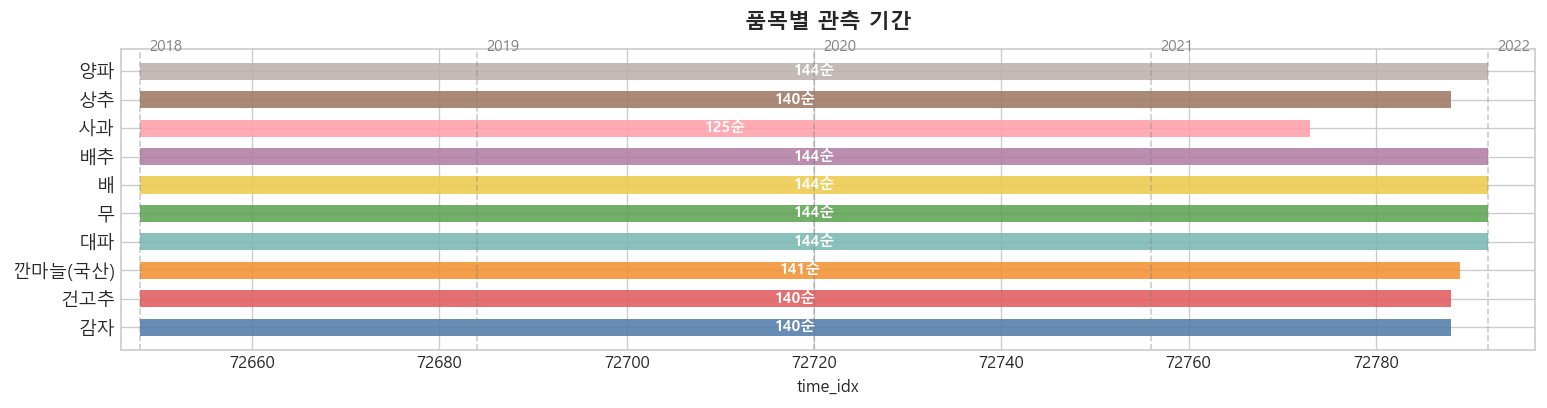

In [16]:
# ── 관측 기간 타임라인 ──
fig, ax = plt.subplots(figsize=(13, 3.5))

for i, item in enumerate(TARGET_ITEMS):
    s = get_series(item)
    ax.barh(i, len(s), left=s['time_idx'].min(), height=0.6,
            color=ITEM_COLORS[item], alpha=0.85)
    ax.text(s['time_idx'].min() + len(s)/2, i, f'{len(s)}순',
            ha='center', va='center', fontsize=9, color='white', fontweight='bold')

# 연도 구분선
for yr in [2018, 2019, 2020, 2021, 2022]:
    ax.axvline(yr * 36, color='gray', linestyle='--', alpha=0.4, lw=1)
    ax.text(yr * 36 + 1, len(TARGET_ITEMS) - 0.3, str(yr), fontsize=9, color='gray')

ax.set_yticks(range(len(TARGET_ITEMS)))
ax.set_yticklabels(TARGET_ITEMS, fontsize=11)
ax.set_xlabel('time_idx', fontsize=10)
ax.set_title('품목별 관측 기간', fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(2018*36 - 2, 2022*36 + 5)
plt.tight_layout()
plt.show()

### 인사이트
- **기간 길이 불균형**: 짧은 관측 기간 품목은 장기 계절성 패턴 학습에 불리 → 품목별 데이터 전략 필요
- **2018~2021 공통 커버**: 코로나 이전(2018~2019) / 이후(2020~2021) 구분 가능한 더미 활용 여지
- **대부분 2021년 말 종료**: 최근 데이터가 없어 트렌드 외삽 시 리스크 큼

###  추가 피처 후보
| 피처 | 설명 | 기존 변수와의 차이 |
|------|------|------------------|
| `is_covid` | 2020년 1월 이후 더미 | 외부 충격 명시적 인코딩 (기존 없음) |
| `days_from_start` | 품목별 첫 관측 이후 경과 순 수 | `time_idx`와 달리 품목별 상대 시간 |
| `season` | 봄/여름/가을/겨울 범주형 | `month`보다 직관적이고 차원 축소 효과 |

---
## 2. 품목별 가격 시계열

- 실제 가격(실선) vs 평년 가격(점선) 비교
- 음영: 실제-평년 차이 (초과 = 빨강, 미만 = 파랑)

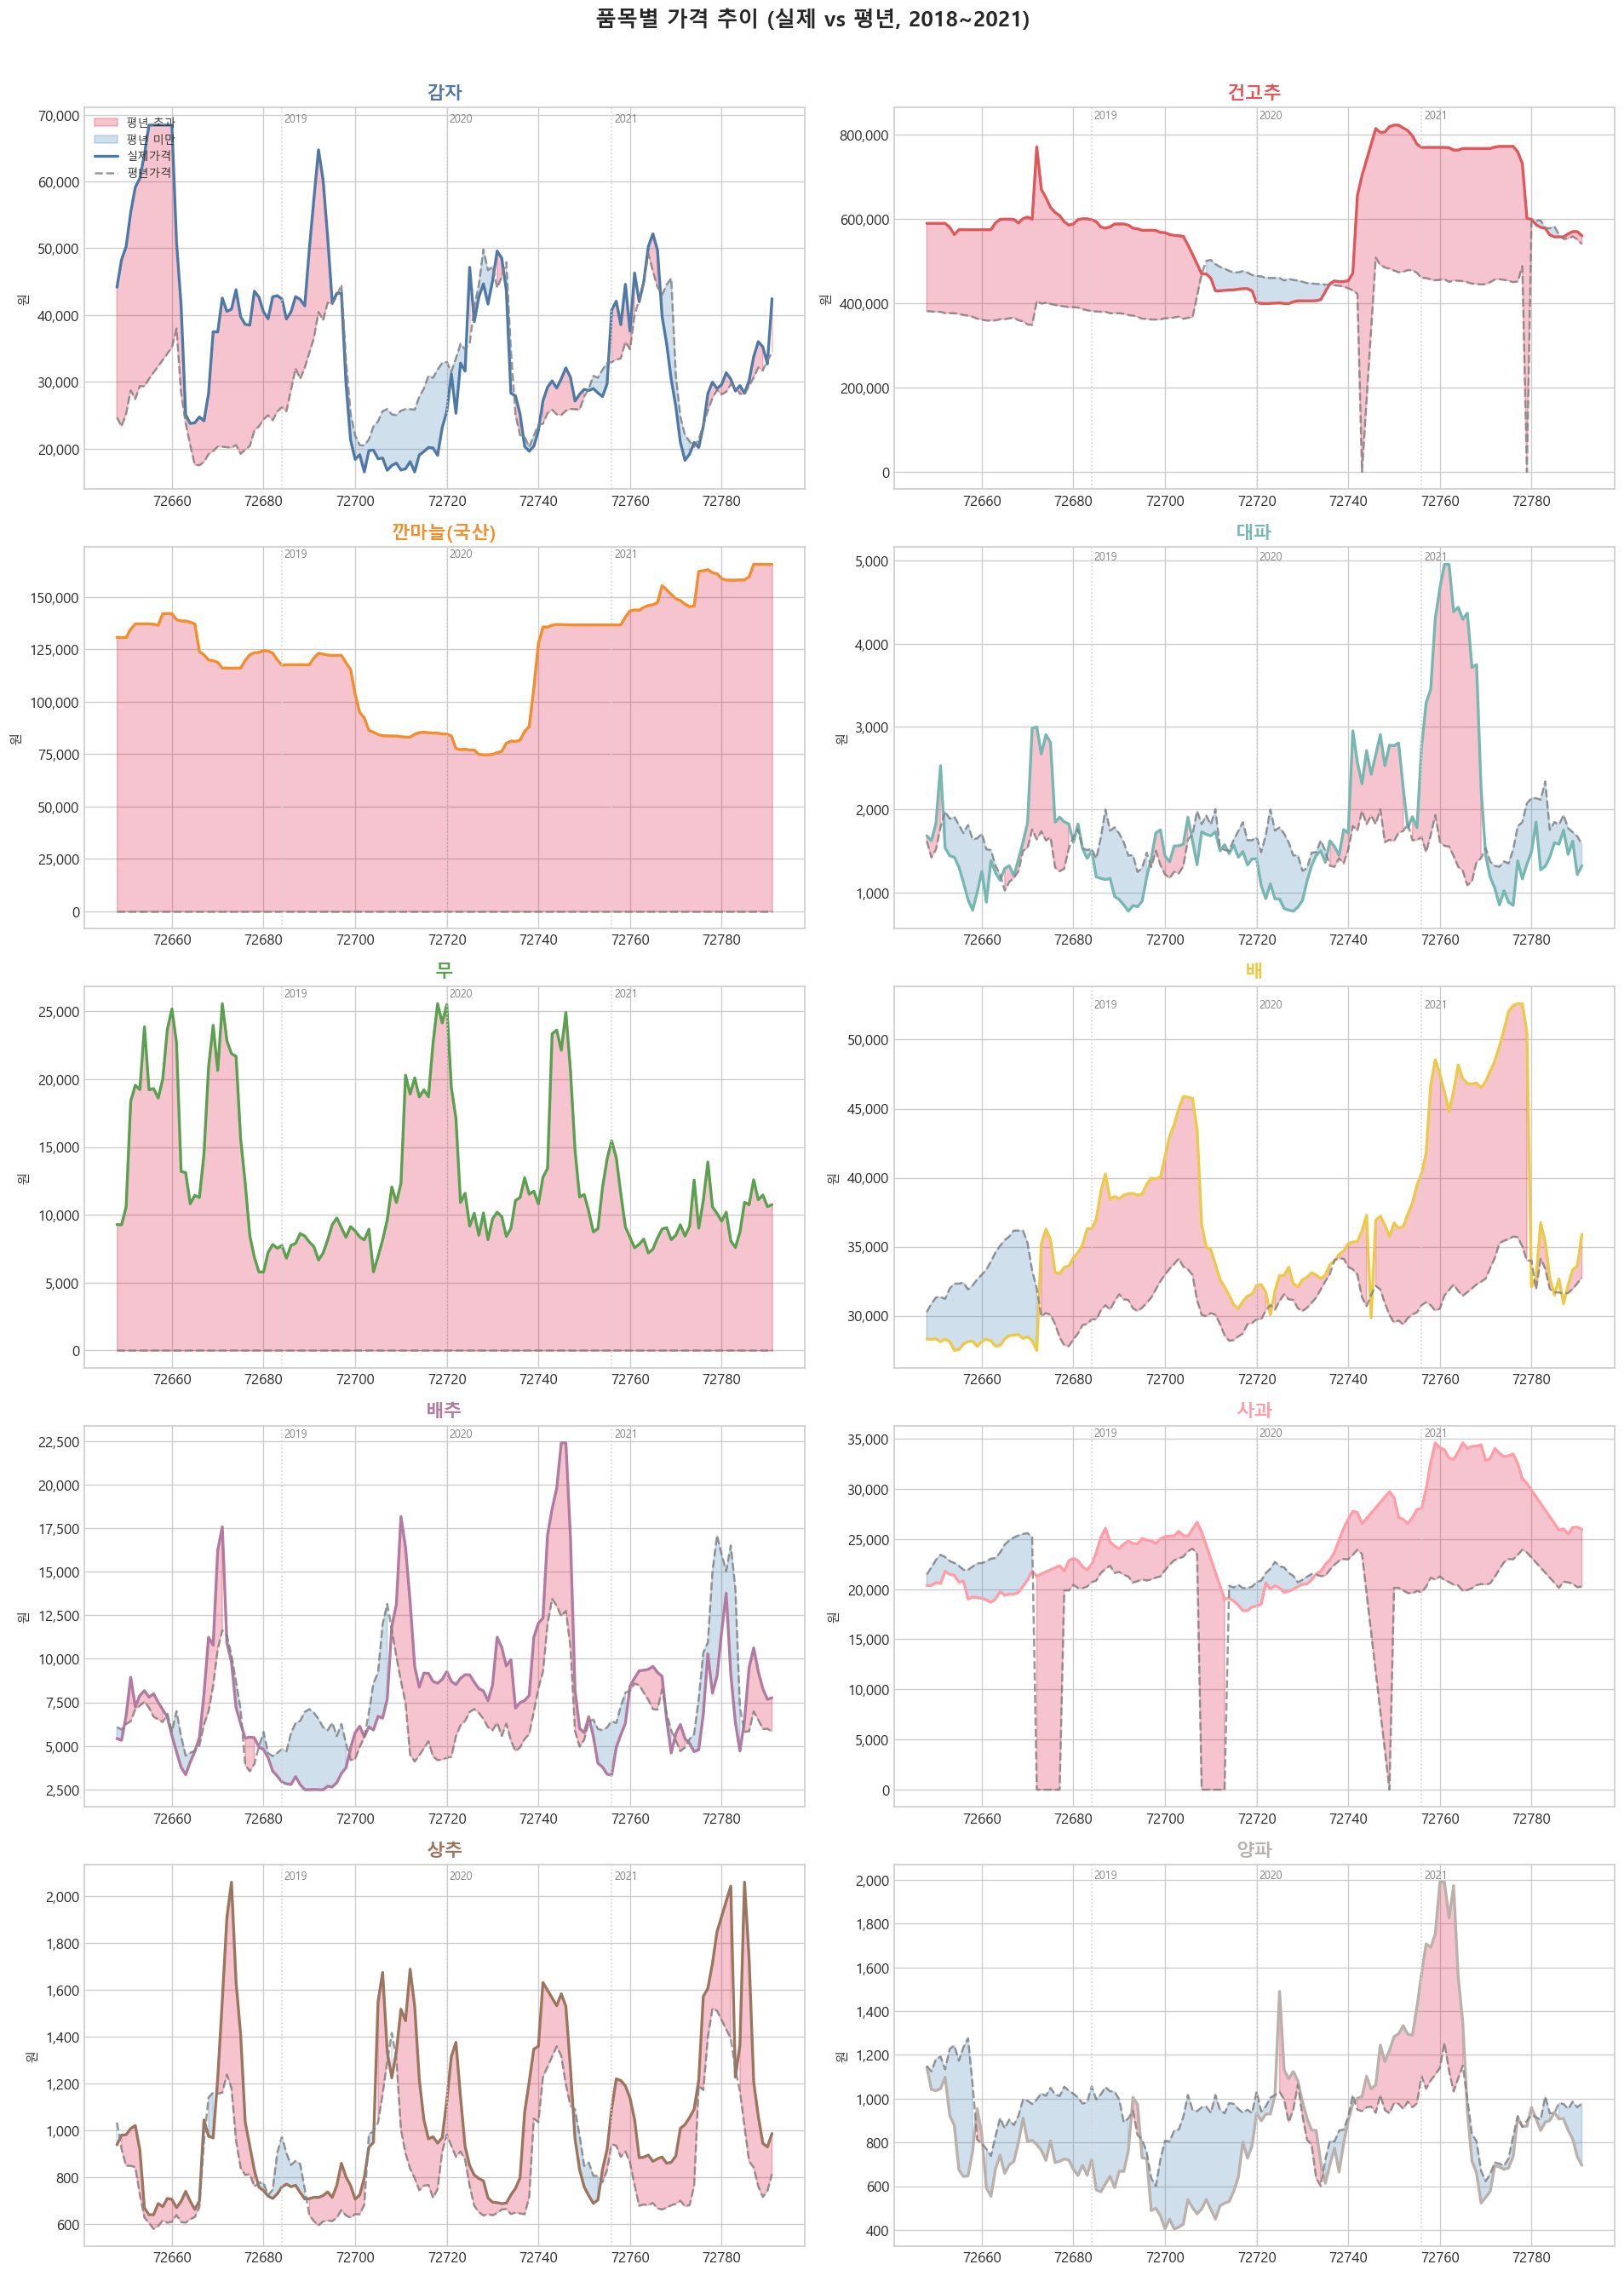

In [17]:
fig, axes = plt.subplots(5, 2, figsize=(16, 22))
axes = axes.flatten()

for i, item in enumerate(TARGET_ITEMS):
    s   = get_series(item)
    ax  = axes[i]
    t   = s['time_idx'].values
    p   = s['평균가격(원)'].values
    avg = s['평년 평균가격(원)'].values

    # 음영 (실제 > 평년 vs 실제 < 평년)
    ax.fill_between(t, p, avg, where=(p >= avg), alpha=0.25, color='crimson', label='평년 초과')
    ax.fill_between(t, p, avg, where=(p < avg),  alpha=0.25, color='steelblue', label='평년 미만')

    ax.plot(t, p,   color=ITEM_COLORS[item], lw=2,   label='실제가격')
    ax.plot(t, avg, color='gray',            lw=1.5, linestyle='--', label='평년가격', alpha=0.8)

    # 연도 구분선
    for yr in [2019, 2020, 2021]:
        ax.axvline(yr * 36, color='lightgray', lw=1, linestyle=':')
        ax.text(yr * 36 + 0.5, ax.get_ylim()[1] * 0.97, str(yr), fontsize=7.5, color='gray')

    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.set_title(item, fontsize=13, fontweight='bold', color=ITEM_COLORS[item])
    ax.set_ylabel('원', fontsize=9)
    if i == 0:
        ax.legend(fontsize=8, loc='upper left')

plt.suptitle('품목별 가격 추이 (실제 vs 평년, 2018~2021)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 인사이트
- **평년 대비 이탈 구간**: 2020년 초(코로나), 여름 집중호우 시기 실제가 급등 — 외부 충격 피처 필요
- **품목별 복귀 속도 차이**: 깻잎·배추는 수주 내 평년 복귀, 사과·배는 장기 이탈 → 품목마다 적정 lag 길이 다름
- **상승·하락 비대칭**: 폭등(상방 이탈)이 폭락보다 극단적 → 손실 함수 설계 시 비대칭 고려

### 추가 피처 후보
| 피처 | 설명 | 기존 변수와의 차이 |
|------|------|------------------|
| `price_diff_1` | 가격 1순 차분 | 절대가격이 아닌 변화량 — 비정상성 제거 효과 |
| `above_normal_dummy` | 평년 초과 여부 (0/1) | `normal_ratio`의 이진화 — 방향성 피처 |
| `trend_ema12` | 12순 지수이동평균 | 단순 이동평균보다 최근 값에 더 높은 가중치 |
| `rolling_std6` | 6순 롤링 표준편차 | 국소 변동성 — 불안정 구간 인식 피처 |

---
## 3. 계절성 분석

**가설**: 농산물 가격은 출하 시기에 따라 뚜렷한 계절 패턴을 가짐  
→ 월별 가격 히트맵 + 개별 품목 계절 패턴 확인

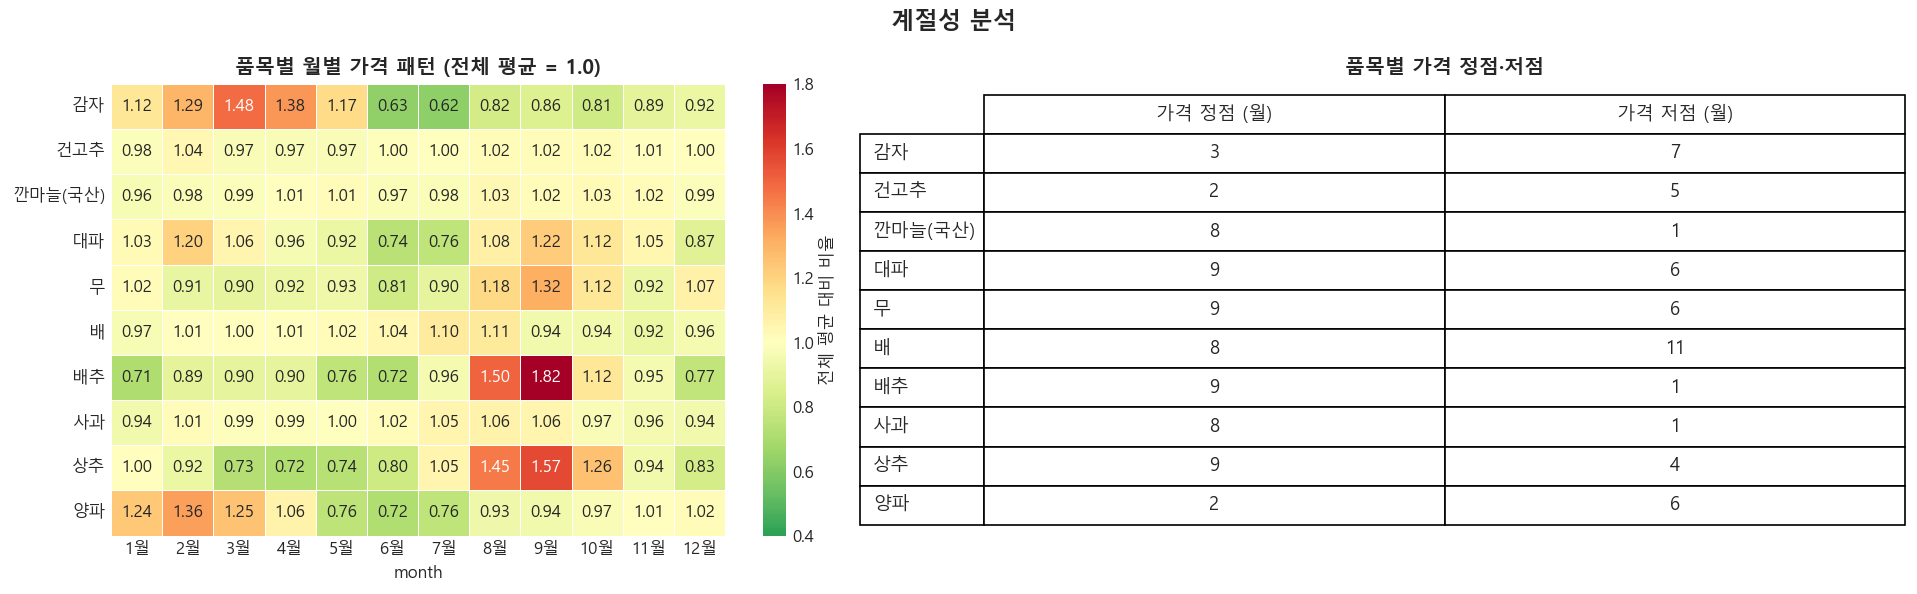

In [18]:
# 품목별 월 평균가격 피벗 (정규화)
monthly = df.groupby(['품목명','month'])['평균가격(원)'].mean().unstack()
monthly_norm = monthly.div(monthly.mean(axis=1), axis=0).reindex(TARGET_ITEMS)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 히트맵
sns.heatmap(
    monthly_norm,
    annot=True, fmt='.2f',
    cmap='RdYlGn_r',
    center=1.0, vmin=0.4, vmax=1.8,
    linewidths=0.5,
    xticklabels=[f'{m}월' for m in range(1,13)],
    ax=axes[0],
    cbar_kws={'label': '전체 평균 대비 비율'}
)
axes[0].set_title('품목별 월별 가격 패턴 (전체 평균 = 1.0)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('')

# 계절 패턴 요약 (가격 정점·저점 월)
peak_month = monthly.idxmax(axis=1).reindex(TARGET_ITEMS)
low_month  = monthly.idxmin(axis=1).reindex(TARGET_ITEMS)
summary = pd.DataFrame({'정점(월)': peak_month, '저점(월)': low_month})

axes[1].axis('off')
table = axes[1].table(
    cellText=summary.values,
    rowLabels=summary.index,
    colLabels=['가격 정점 (월)', '가격 저점 (월)'],
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.0)
axes[1].set_title('품목별 가격 정점·저점', fontsize=12, fontweight='bold')

plt.suptitle('계절성 분석', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 인사이트
- **계절성 구조 뚜렷**: 김장철 품목(배추·무)은 10~11월 고가, 여름 채소는 7~8월 고가 — 품목별 최고/최저 월 명시적 인코딩 필요
- **정규화 비율 1.0 이상 구간**: 구조적으로 평년보다 비싼 시기 → 모델이 양의 편향을 학습할 위험
- **월별 패턴 품목 간 이질성**: 하나의 계절성 피처로 모든 품목 커버 불가 → 품목×월 교호작용 피처 유효

### 추가 피처 후보
| 피처 | 설명 | 기존 변수와의 차이 |
|------|------|------------------|
| `month_sin`, `month_cos` | 월의 sin/cos 인코딩 | `month`(정수)와 달리 **순환 구조** 반영 |
| `item_month_avg` | 품목×월 평균가 | 전체 월 평균이 아닌 품목별 계절 기준점 |
| `pct_from_item_month_avg` | 현재가 / 품목×월 평균 | 계절 내 상대적 위치 (평년가와 보완적) |
| `is_kimchi_season` | 10~11월 더미 | 배추·무에 특화된 이벤트 피처 |

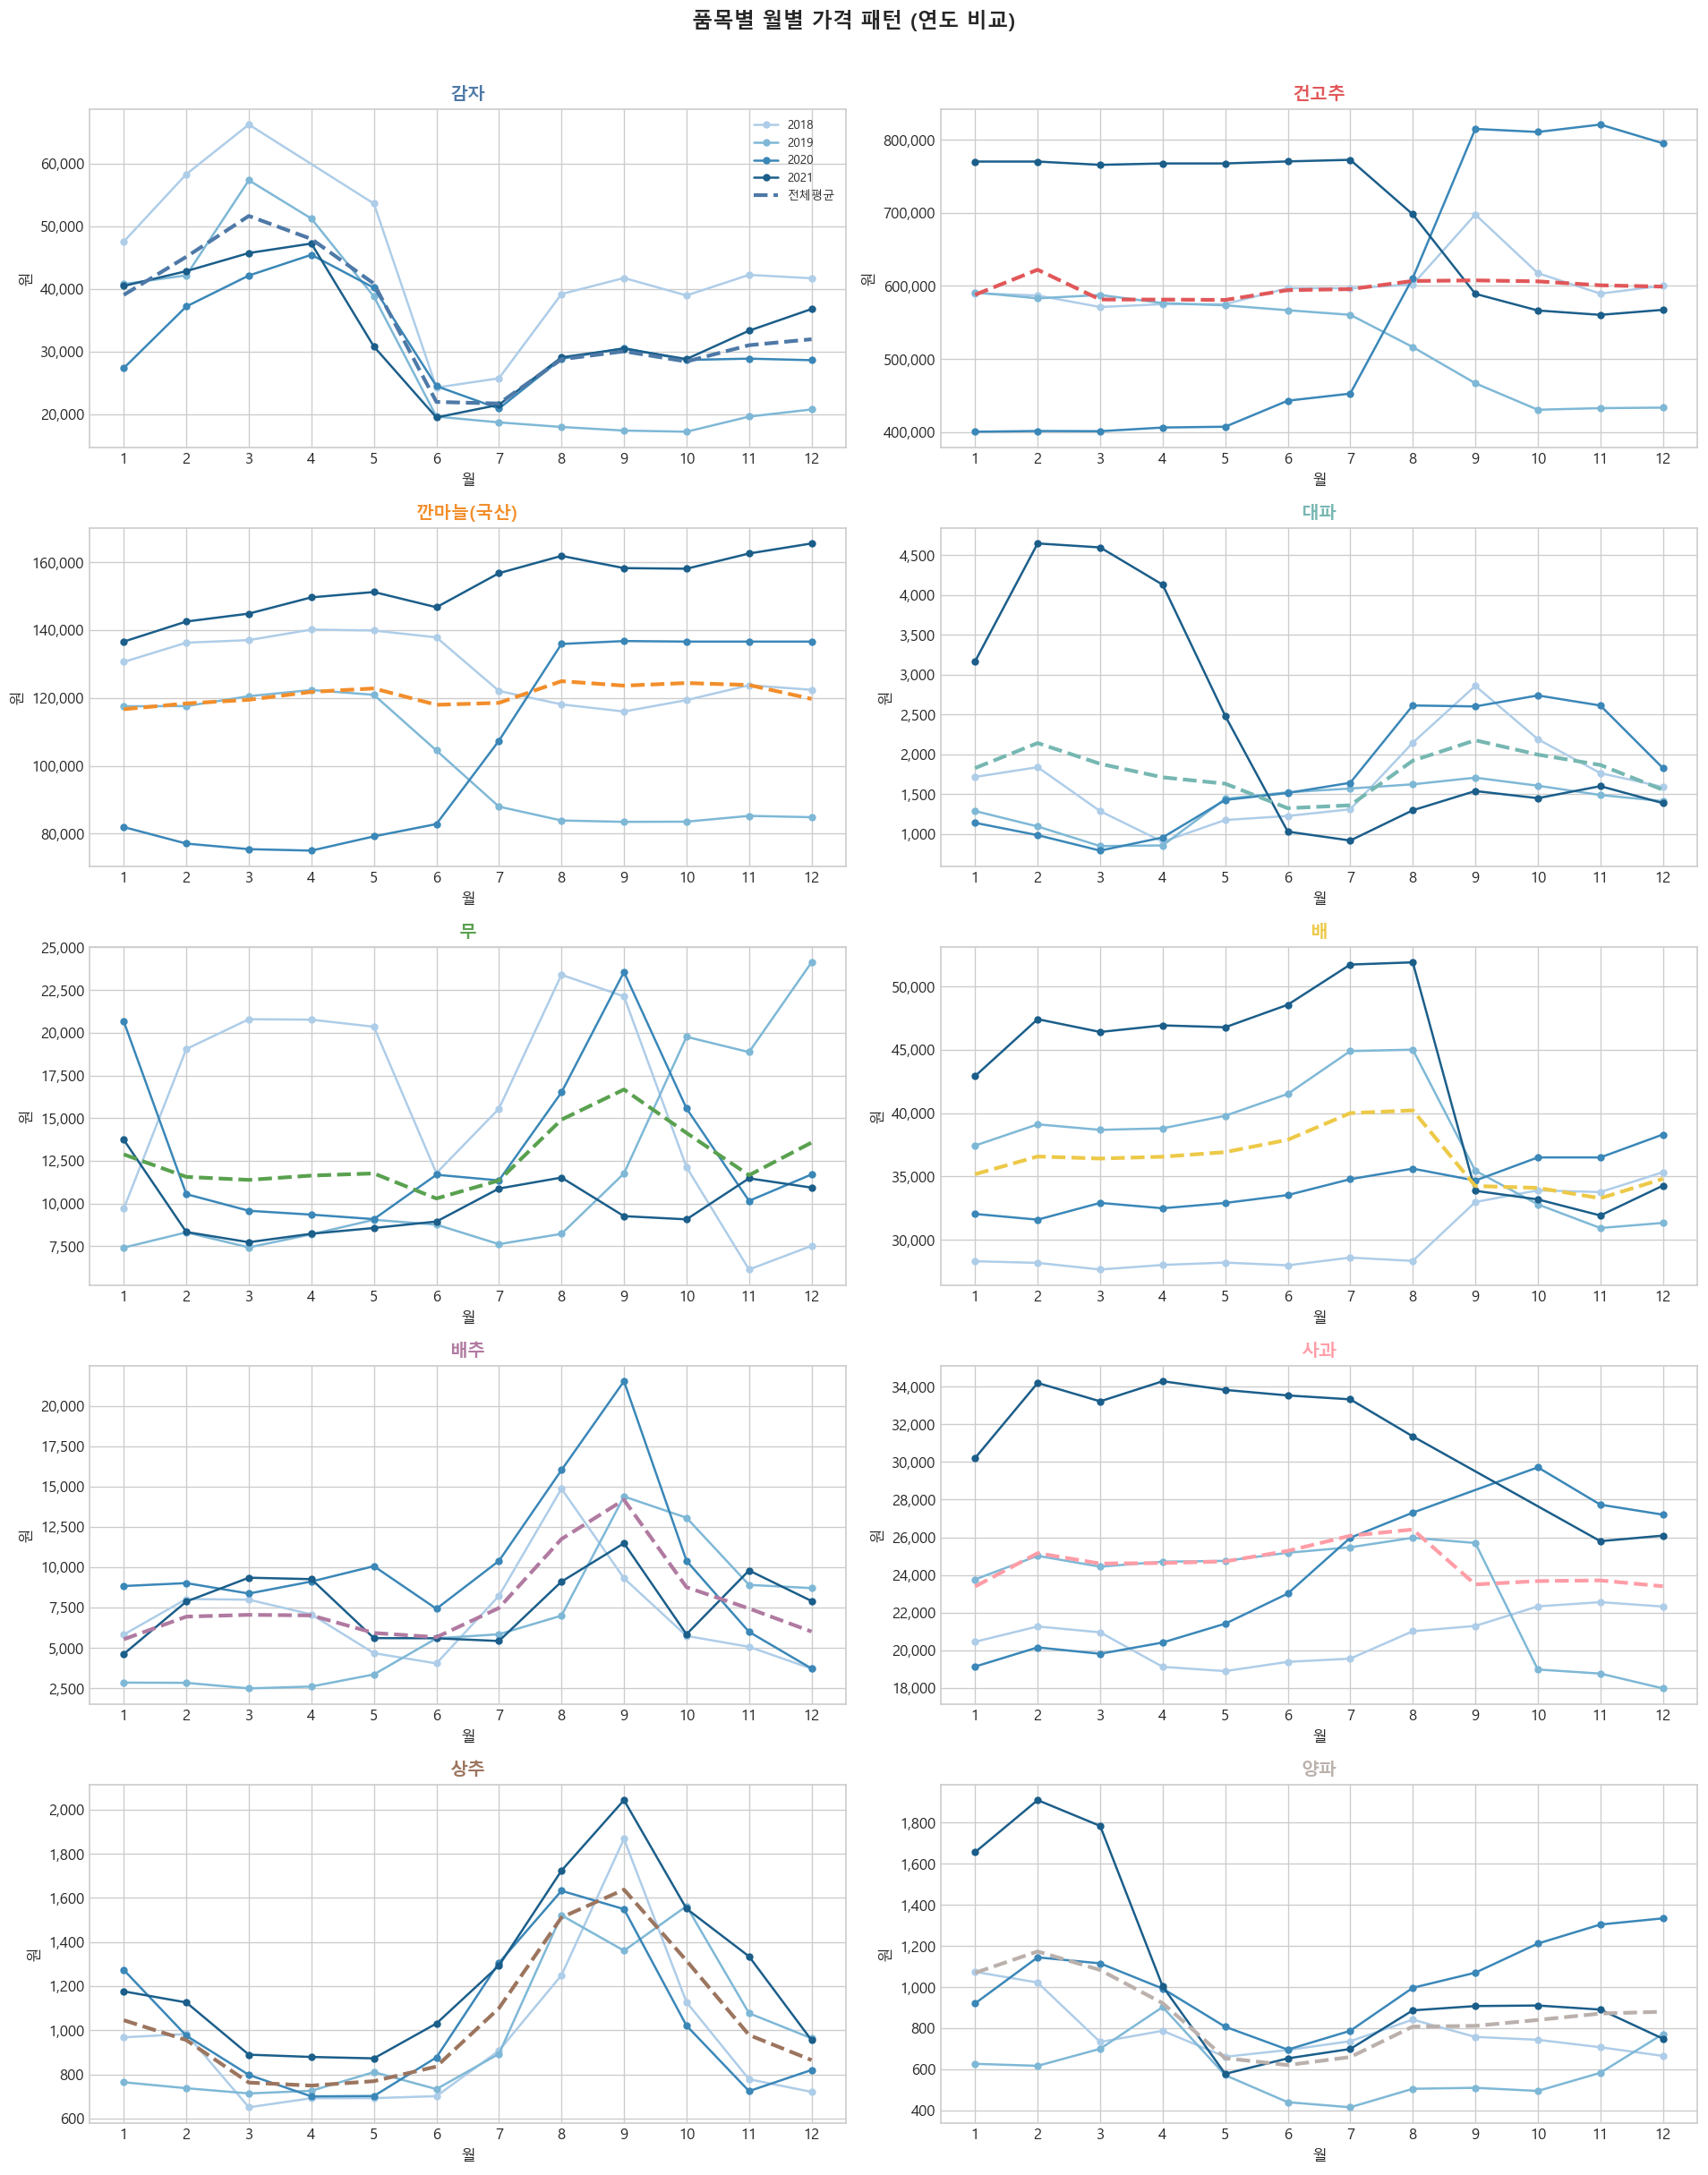

In [19]:
# 개별 품목 월별 패턴 (연도별 비교)
fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()
month_labels = ['1','2','3','4','5','6','7','8','9','10','11','12']

for i, item in enumerate(TARGET_ITEMS):
    s   = get_series(item)
    ax  = axes[i]
    clr = ITEM_COLORS[item]

    # 연도별 라인
    yr_palette = ['#AECDE8','#7EB8D6','#3A87B8','#1B5E8A']
    for j, yr in enumerate([2018, 2019, 2020, 2021]):
        yr_s = s[s['year'] == yr].groupby('month')['평균가격(원)'].mean()
        ax.plot(yr_s.index, yr_s.values, color=yr_palette[j],
                lw=1.5, marker='o', ms=4, label=str(yr))

    # 전체 평균
    mean_s = s.groupby('month')['평균가격(원)'].mean()
    ax.plot(mean_s.index, mean_s.values, color=clr, lw=2.5,
            linestyle='--', label='전체평균', zorder=5)

    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels)
    ax.set_title(item, fontsize=12, fontweight='bold', color=clr)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.set_xlabel('월')
    ax.set_ylabel('원')
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle('품목별 월별 가격 패턴 (연도 비교)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 인사이트
- **계절 패턴 강도 차이**: 배추는 U자형, 감자는 여름 단봉형 — 품목별 계절성 구조가 근본적으로 다름
- **순(旬) 내 가격 차이**: 같은 월이라도 상순/중순/하순에 차이 → `순_num` 피처를 순환 인코딩으로 개선 필요
- **분산 높은 특정 월**: 일부 품목의 특정 월은 spread가 크게 넓음 → 월별 변동계수 피처로 불확실성 포착

### 추가 피처 후보
| 피처 | 설명 | 기존 변수와의 차이 |
|------|------|------------------|
| `sun_sin`, `sun_cos` | 순(1~3)의 sin/cos 인코딩 | `순_num`(정수 1~3)의 순환 구조 개선 버전 |
| `item_month_sun_avg` | 품목×월×순 평균가 | 가장 세밀한 계절 기준점 |
| `month_cv_per_item` | 품목별 월별 변동계수 | 해당 월의 역사적 불확실성 직접 인코딩 |

---
## 4. 연도별 트렌드

- 연도별 평균가격 vs 전체 평균 비교
- **1.0보다 크게 벗어나는 구간** = 이상 급등/급락 연도

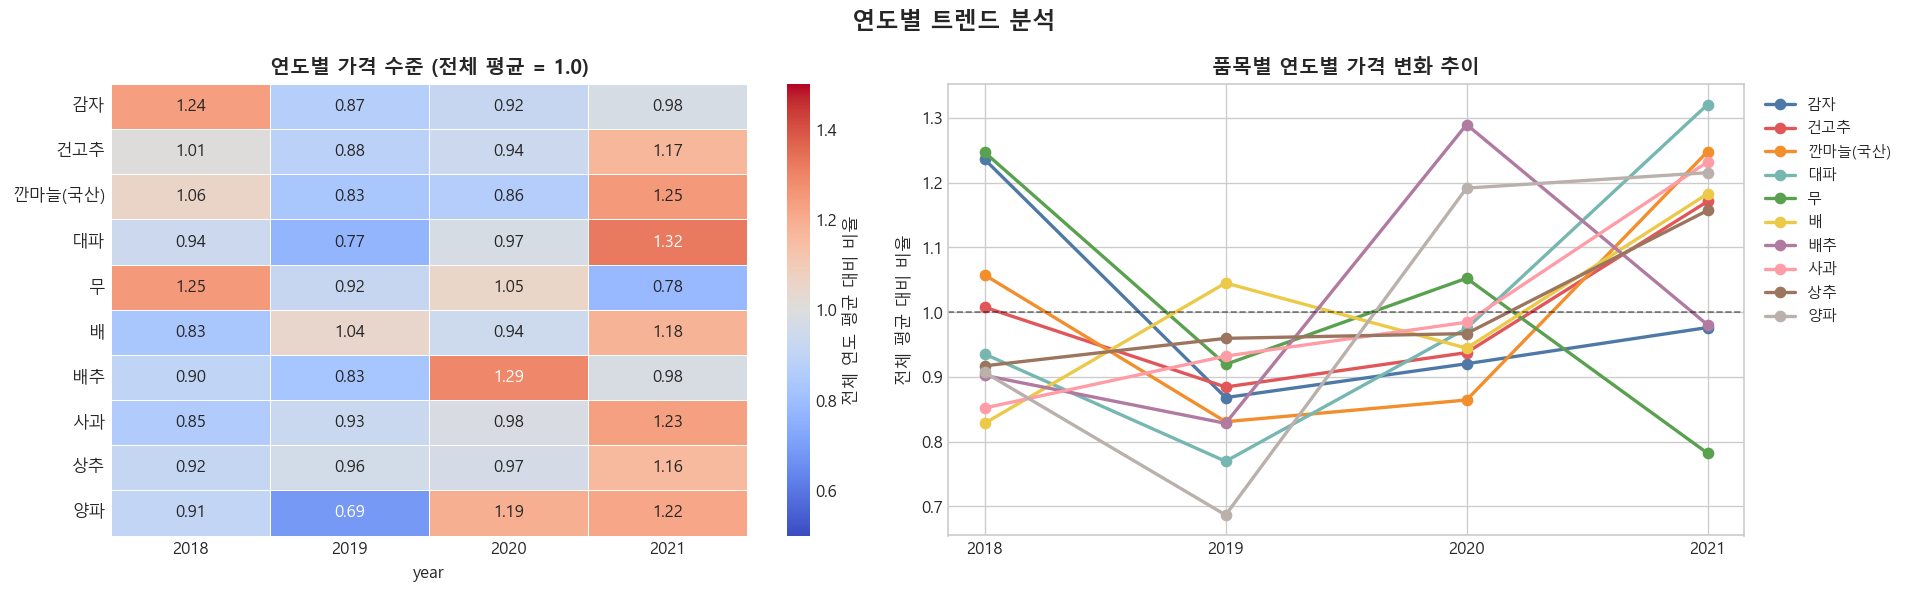

[인사이트] 1.2 이상이면 해당 연도에 급등, 0.8 이하이면 급락
  대파: {2021: 1.320610675713982}
  배추: {2020: 1.2896603676875495}


In [20]:
yearly = df.groupby(['품목명','year'])['평균가격(원)'].mean().unstack().reindex(TARGET_ITEMS)
yearly_norm = yearly.div(yearly.mean(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 히트맵
sns.heatmap(
    yearly_norm,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=1.0, vmin=0.5, vmax=1.5,
    linewidths=0.5,
    ax=axes[0],
    cbar_kws={'label': '전체 연도 평균 대비 비율'}
)
axes[0].set_title('연도별 가격 수준 (전체 평균 = 1.0)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('')

# 라인차트 (연도별 트렌드)
for item in TARGET_ITEMS:
    axes[1].plot([2018,2019,2020,2021], yearly_norm.loc[item],
                 marker='o', lw=2, color=ITEM_COLORS[item], label=item)
axes[1].axhline(1.0, color='black', linestyle='--', lw=1, alpha=0.5)
axes[1].set_xticks([2018,2019,2020,2021])
axes[1].set_title('품목별 연도별 가격 변화 추이', fontsize=12, fontweight='bold')
axes[1].set_ylabel('전체 평균 대비 비율')
axes[1].legend(fontsize=9, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.suptitle('연도별 트렌드 분석', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('[인사이트] 1.2 이상이면 해당 연도에 급등, 0.8 이하이면 급락')
for item in TARGET_ITEMS:
    anomaly = yearly_norm.loc[item][yearly_norm.loc[item].abs() > 1.25]
    if len(anomaly) > 0:
        print(f'  {item}: {anomaly.to_dict()}')

### 인사이트
- **2020년 이상 급등·급락**: 코로나 영향으로 수급 교란 — 연도 더미보다 **사건 더미**가 더 유효
- **구조적 가격 상승 트렌드**: 2018→2021 전반적 우상향 → 선형 트렌드 변수 미적용 시 미래 과소 예측 위험
- **품목별 연도 효과 이질성**: 사과·배는 연도별 변동 크고, 깻잎은 안정적 → 전체 트렌드보다 품목별 추정 유효

### 추가 피처 후보
| 피처 | 설명 | 기존 변수와의 차이 |
|------|------|------------------|
| `year_trend` | 연도 − 2018 (0, 1, 2, 3) | 연도 더미보다 단조 증가 트렌드 직접 인코딩 |
| `is_2020` | 2020년 더미 | 코로나 충격을 명시적으로 분리 (기존 없음) |
| `yoy_change` | 전년 동기 대비 변화율 | 절대가가 아닌 연간 상대 변화량 |
| `cpi_index` | 외부 소비자물가지수 | 기존 변수에 없는 거시경제 컨텍스트 피처 |

---
## 5. 가격 분포 & 변동성

- **변동계수(CV = std/mean)**: 예측 난이도 지표
- CV가 높은 품목 = 변동성 크고 예측이 어려움 → 변동성 피처 필요

C:\Users\user\AppData\Local\Temp\ipykernel_25520\2057751206.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(cv.index, rotation=35, ha='right', fontsize=10)


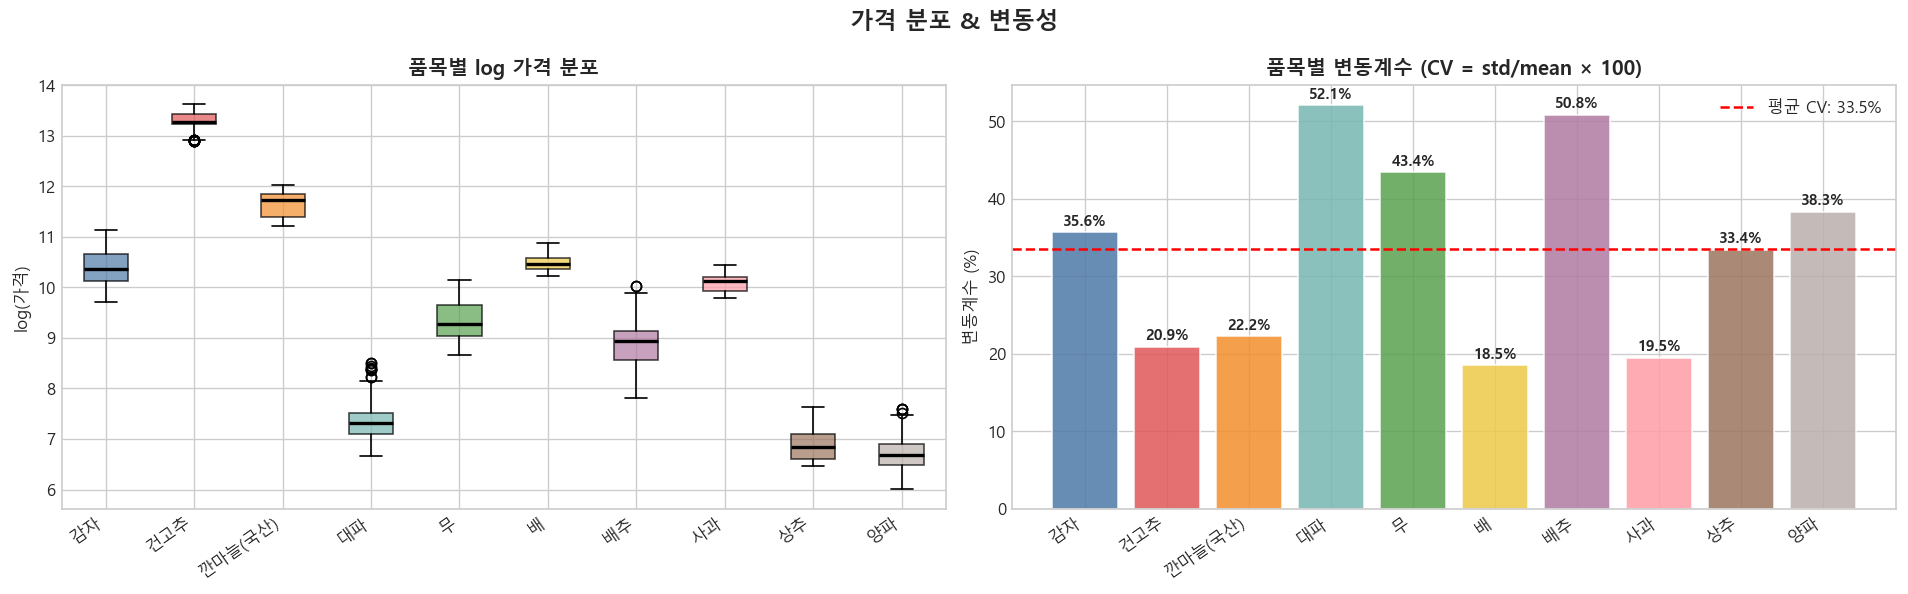


[변동성 순위] CV 높을수록 예측 난이도 높음
품목명
대파         52.1
배추         50.8
무          43.4
양파         38.3
감자         35.6
상추         33.4
깐마늘(국산)    22.2
건고추        20.9
사과         19.5
배          18.5


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 박스플롯 (로그 스케일)
box_data = [np.log1p(df[df['품목명']==item]['평균가격(원)'].values) for item in TARGET_ITEMS]
bp = axes[0].boxplot(box_data, patch_artist=True, notch=False,
                     medianprops=dict(color='black', lw=2))
for patch, item in zip(bp['boxes'], TARGET_ITEMS):
    patch.set_facecolor(ITEM_COLORS[item])
    patch.set_alpha(0.7)
axes[0].set_xticklabels(TARGET_ITEMS, rotation=35, ha='right', fontsize=10)
axes[0].set_ylabel('log(가격)')
axes[0].set_title('품목별 log 가격 분포', fontsize=12, fontweight='bold')

# 변동계수 바 차트
cv = df.groupby('품목명')['평균가격(원)'].agg(lambda x: x.std()/x.mean()*100).reindex(TARGET_ITEMS)
colors = [ITEM_COLORS[i] for i in cv.index]
bars = axes[1].bar(cv.index, cv.values, color=colors, alpha=0.85, edgecolor='white')
axes[1].axhline(cv.mean(), color='red', linestyle='--', lw=1.5, label=f'평균 CV: {cv.mean():.1f}%')
for bar, val in zip(bars, cv.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.3, f'{val:.1f}%',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_xticklabels(cv.index, rotation=35, ha='right', fontsize=10)
axes[1].set_ylabel('변동계수 (%)')
axes[1].set_title('품목별 변동계수 (CV = std/mean × 100)', fontsize=12, fontweight='bold')
axes[1].legend()

plt.suptitle('가격 분포 & 변동성', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n[변동성 순위] CV 높을수록 예측 난이도 높음')
print(cv.sort_values(ascending=False).round(1).to_string())

### 인사이트
- **log 변환 효과 확인**: log 가격 분포가 훨씬 대칭적 → 회귀 모델 입력·타깃 모두 log 사용 권장
- **CV 높은 품목(배추·무)**: 이상값 처리 전략이 성능에 크게 영향 → IQR 기준 clip 또는 이상값 더미 피처 고려
- **CV 낮은 품목(깻잎·느타리)**: 안정적이나 외부 충격에 민감할 수 있음 → 충격 이후 복귀 속도 피처 유효

###  추가 피처 후보
| 피처 | 설명 | 기존 변수와의 차이 |
|------|------|------------------|
| `log_price` | log1p(가격) | 이미 있음 — **타깃으로 사용** 권장 (잔차 정규성 개선) |
| `is_outlier_iqr` | IQR 기준 이상값 더미 | 이상값 학습 vs 제외 여부 판단 보조 피처 |
| `rolling_cv6` | 6순 롤링 변동계수 | 정적 CV와 달리 **시간에 따른 변동성 변화** 포착 |
| `price_percentile` | 품목별 누적분포 분위수 위치 | 절대가보다 분포 내 상대 위치 정보 |

---
## 6. 평년가격 vs 실제가격

- `normal_ratio = (실제 - 평년) / 평년`
- 평년가격이 얼마나 좋은 reference인지 확인
- 분포가 0 근처에 집중 → 평년가격이 유효한 baseline

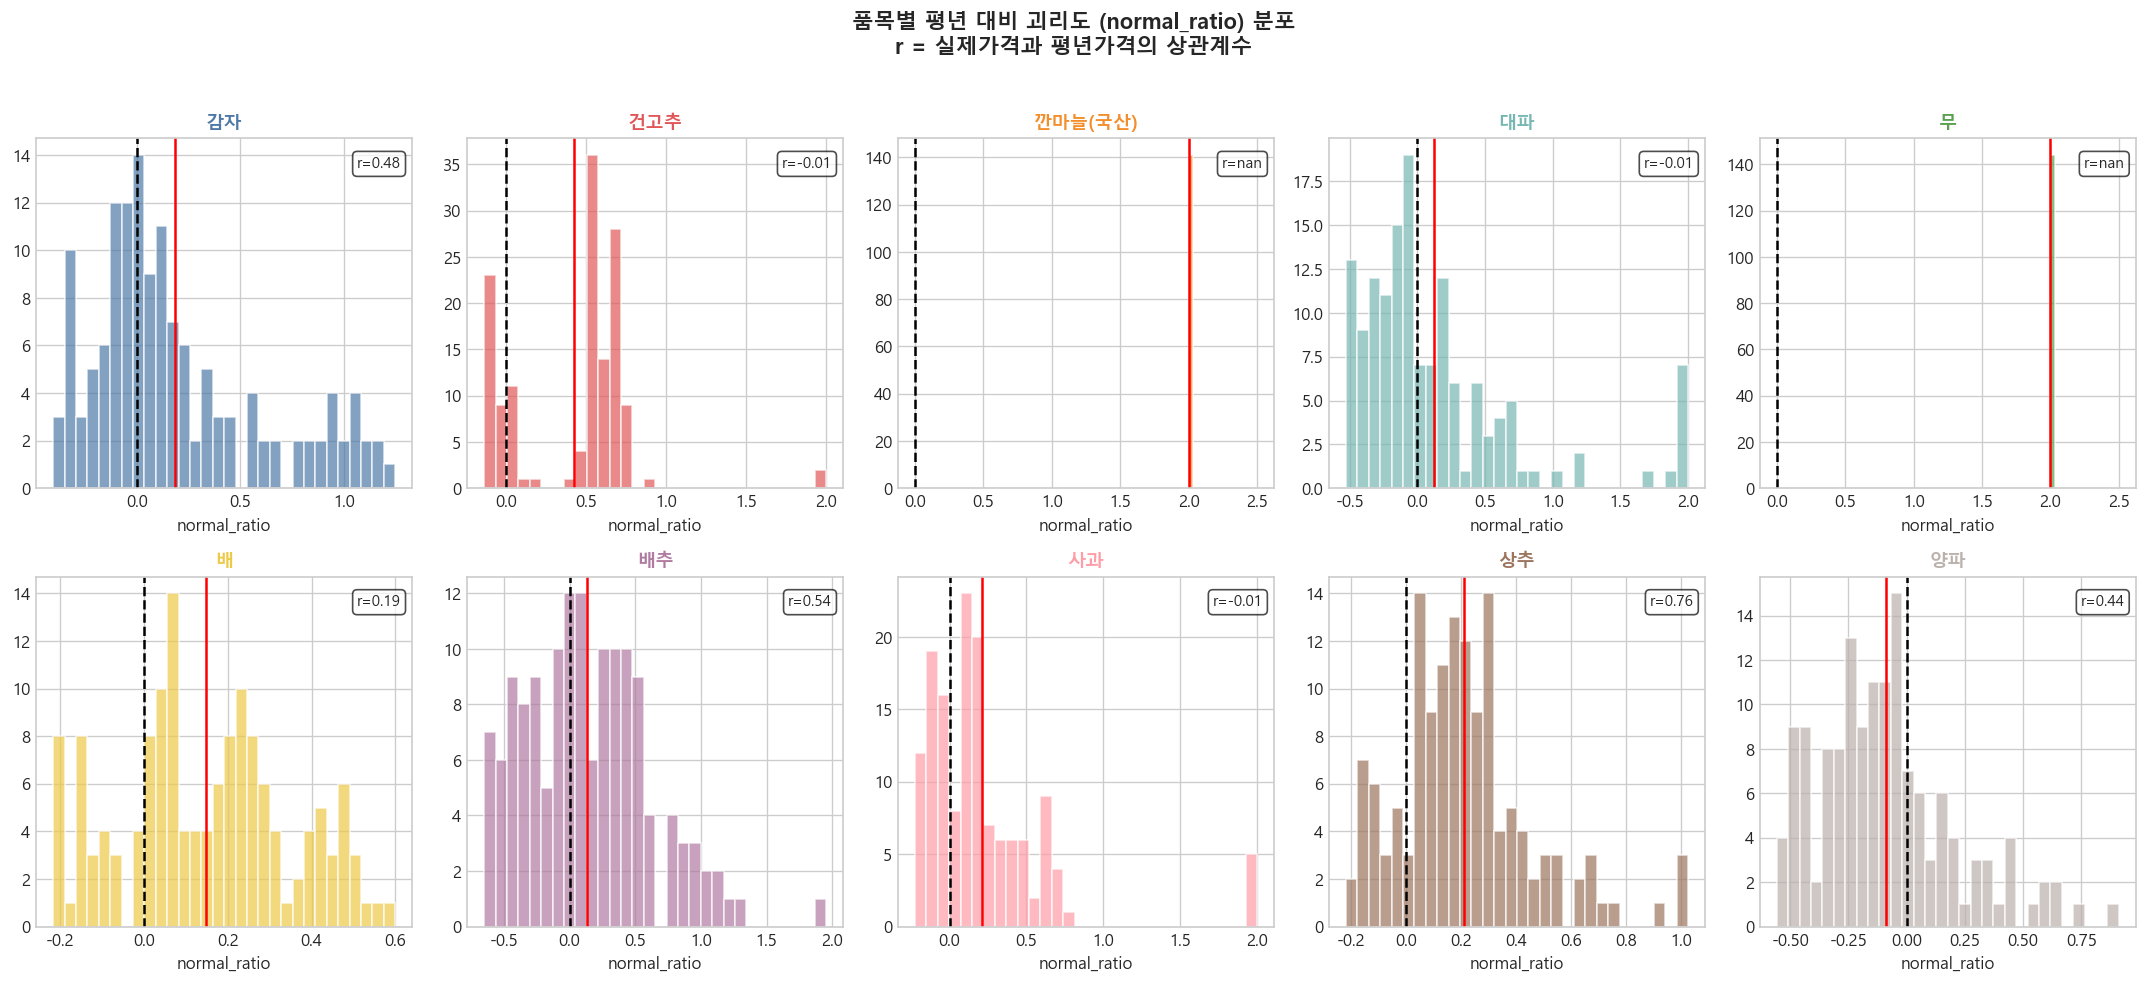

[해석]
  r 높음 → 평년가격이 좋은 피처 → normal_ratio 피처 유효
  평균 > 0 → 해당 품목 전반적으로 평년보다 비쌈


In [22]:
df['normal_ratio'] = (df['평균가격(원)'] - df['평년 평균가격(원)']) / (df['평년 평균가격(원)'] + 1e-6)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, item in enumerate(TARGET_ITEMS):
    sub  = df[df['품목명'] == item]
    nr   = sub['normal_ratio'].clip(-2, 2)
    clr  = ITEM_COLORS[item]
    ax   = axes[i]

    ax.hist(nr, bins=30, color=clr, alpha=0.7, edgecolor='white')
    ax.axvline(0,        color='black', lw=1.5, linestyle='--', label='기준(0)')
    ax.axvline(nr.mean(),color='red',   lw=1.5, linestyle='-',  label=f'평균 {nr.mean():.2f}')

    ax.set_title(f'{item}', fontsize=11, fontweight='bold', color=clr)
    ax.set_xlabel('normal_ratio')

    # 상관계수 표시
    r = sub[['평균가격(원)','평년 평균가격(원)']].corr().iloc[0,1]
    ax.text(0.97, 0.95, f'r={r:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.suptitle('품목별 평년 대비 괴리도 (normal_ratio) 분포\n'
             'r = 실제가격과 평년가격의 상관계수', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('[해석]')
print('  r 높음 → 평년가격이 좋은 피처 → normal_ratio 피처 유효')
print('  평균 > 0 → 해당 품목 전반적으로 평년보다 비쌈')

### 인사이트
- **오른쪽 꼬리 품목**: 구조적 고가 경향 → 평년가가 과소 추정 베이스라인으로 작용
- **r값 낮은 품목**: 평년가와 실제가 상관이 낮음 → 해당 품목은 lag·계절성 피처에 더 의존 필요
- **mean > 0 품목**: 구조적으로 평년보다 비싸게 거래 → 잔차 학습 또는 편향 보정 전략 필요

###  추가 피처 후보
| 피처 | 설명 | 기존 변수와의 차이 |
|------|------|------------------|
| `normal_ratio` | 이미 계산됨 → **직접 피처로 활용** | 실제가 대신 평년 대비 편차를 학습 타깃으로도 가능 |
| `normal_ratio_lag1` | 1순 전 normal_ratio | 현재 편차의 지속성(관성) 포착 |
| `normal_ratio_rolling3` | 3순 롤링 평균 normal_ratio | 단기 편차 추세 요약 |
| `is_above_normal` | normal_ratio > 0 더미 | 이진 방향성 피처 또는 보조 분류 타깃 |

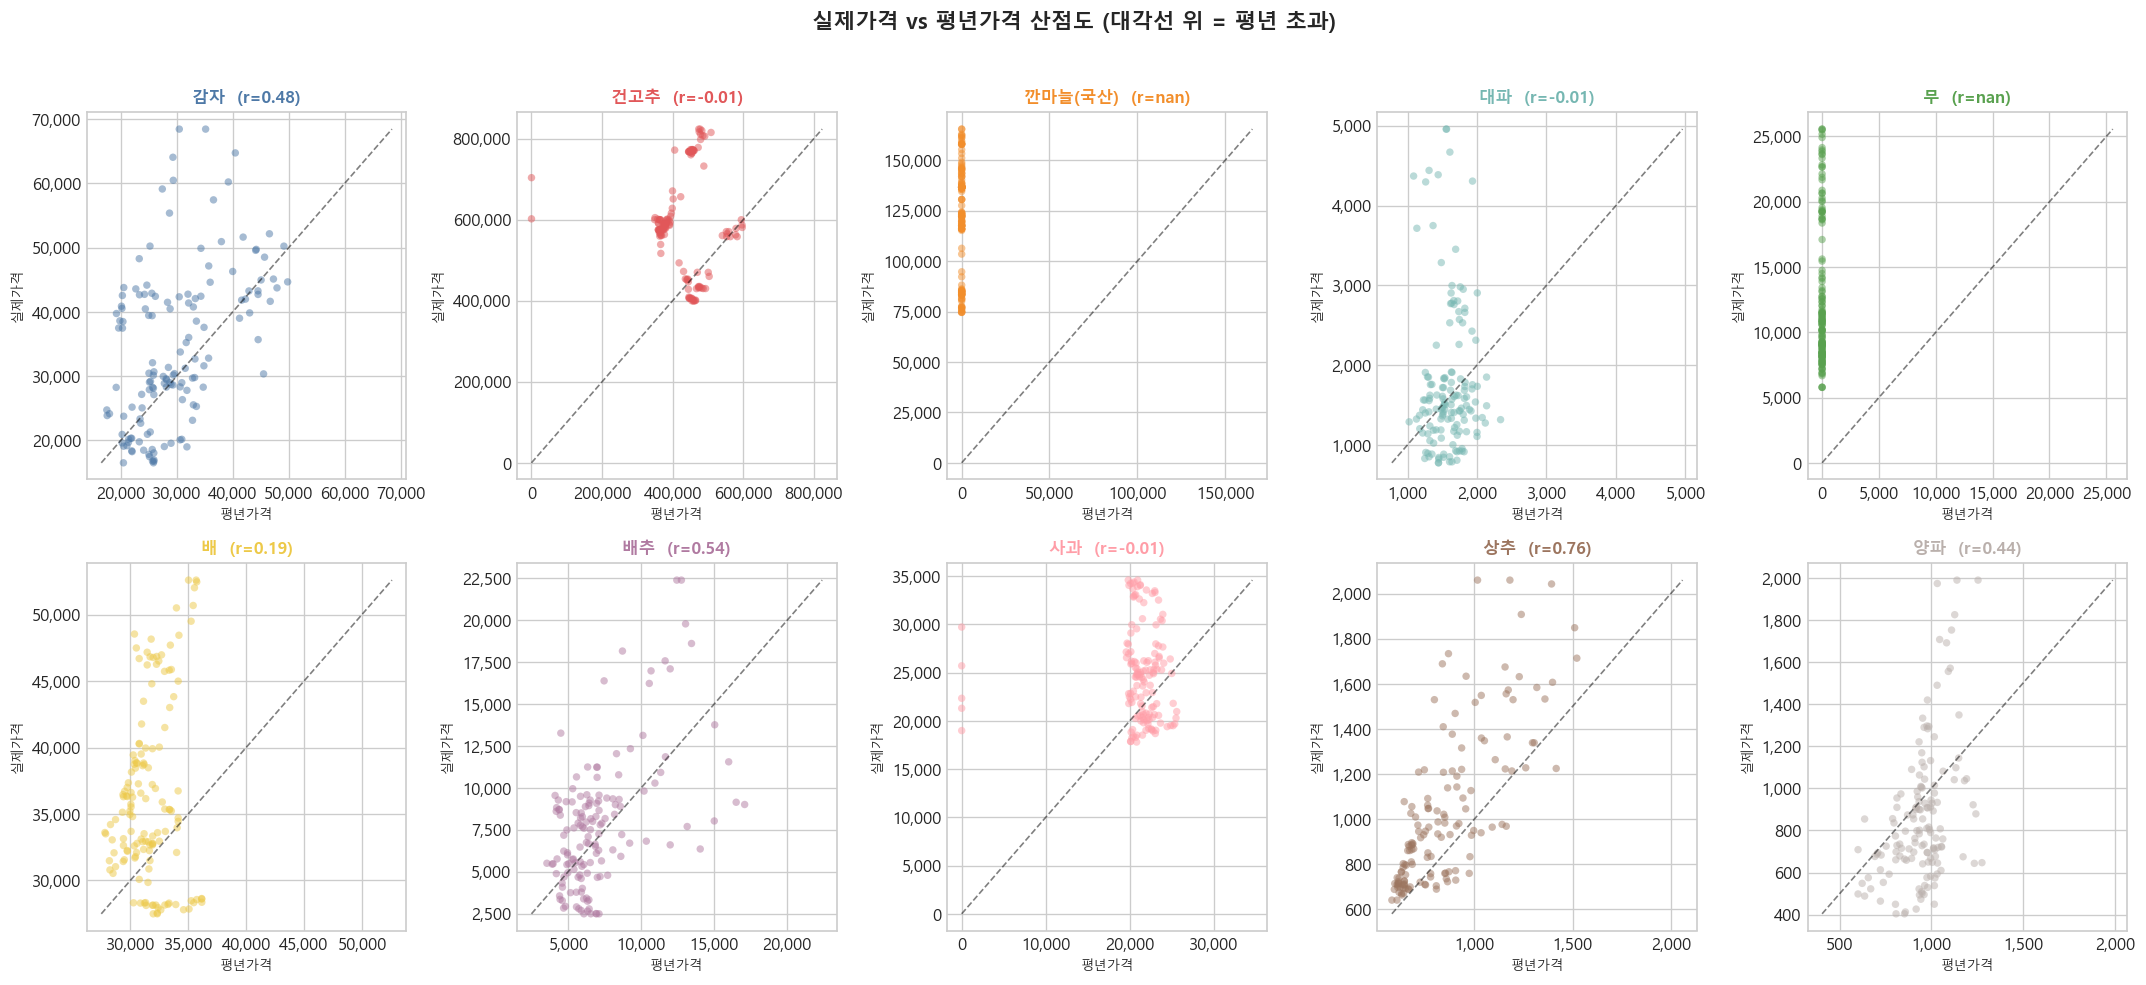

In [23]:
# 실제가격 vs 평년가격 산점도
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, item in enumerate(TARGET_ITEMS):
    sub = df[df['품목명'] == item]
    clr = ITEM_COLORS[item]
    ax  = axes[i]

    ax.scatter(sub['평년 평균가격(원)'], sub['평균가격(원)'],
               alpha=0.5, color=clr, s=20, edgecolors='none')

    # y=x 기준선
    mn = min(sub['평년 평균가격(원)'].min(), sub['평균가격(원)'].min())
    mx = max(sub['평년 평균가격(원)'].max(), sub['평균가격(원)'].max())
    ax.plot([mn, mx], [mn, mx], 'k--', lw=1, alpha=0.5, label='y=x')

    r = sub[['평균가격(원)','평년 평균가격(원)']].corr().iloc[0,1]
    ax.set_title(f'{item}  (r={r:.2f})', fontsize=10, fontweight='bold', color=clr)
    ax.set_xlabel('평년가격', fontsize=8)
    ax.set_ylabel('실제가격', fontsize=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('실제가격 vs 평년가격 산점도 (대각선 위 = 평년 초과)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 인사이트
- **r >= 0.9 품목**: 평년가가 강력한 베이스라인 → `실제 = 평년 × (1 + 편차)` 형태의 모델링 접근 유효
- **r < 0.6 품목**: 평년가 신뢰도 낮음 → 시계열 lag·계절성 피처에 더 의존 필요
- **y=x 대각선 상방 이탈 패턴**: 특정 가격대에서만 고가 경향 → 비선형 관계 주의, 트리 기반 모델 유리

###  추가 피처 후보
| 피처 | 설명 | 기존 변수와의 차이 |
|------|------|------------------|
| `log_normal_price` | log1p(평년가) | 평년가 그대로보다 스케일 안정화 |
| `normal_residual` | 실제가 − 평년가 (절대 편차) | `normal_ratio`와 달리 원 단위 편차 |
| `normal_price_ma3` | 3순 평년가 이동평균 | 단일 평년가보다 평활화된 기준선 제공 |
| `normal_price_corr_flag` | r < 0.7인 품목 더미 | 평년가 신뢰도 낮은 품목 명시적 인코딩 |

---
## 7. 자기상관 (Lag 분석)

- **어떤 lag까지 예측력이 있는지** 확인
- ACF(자기상관함수): lag k 시점 이전 가격과 현재 가격의 상관
- 점선 = 통계적 유의 기준 (±0.2)

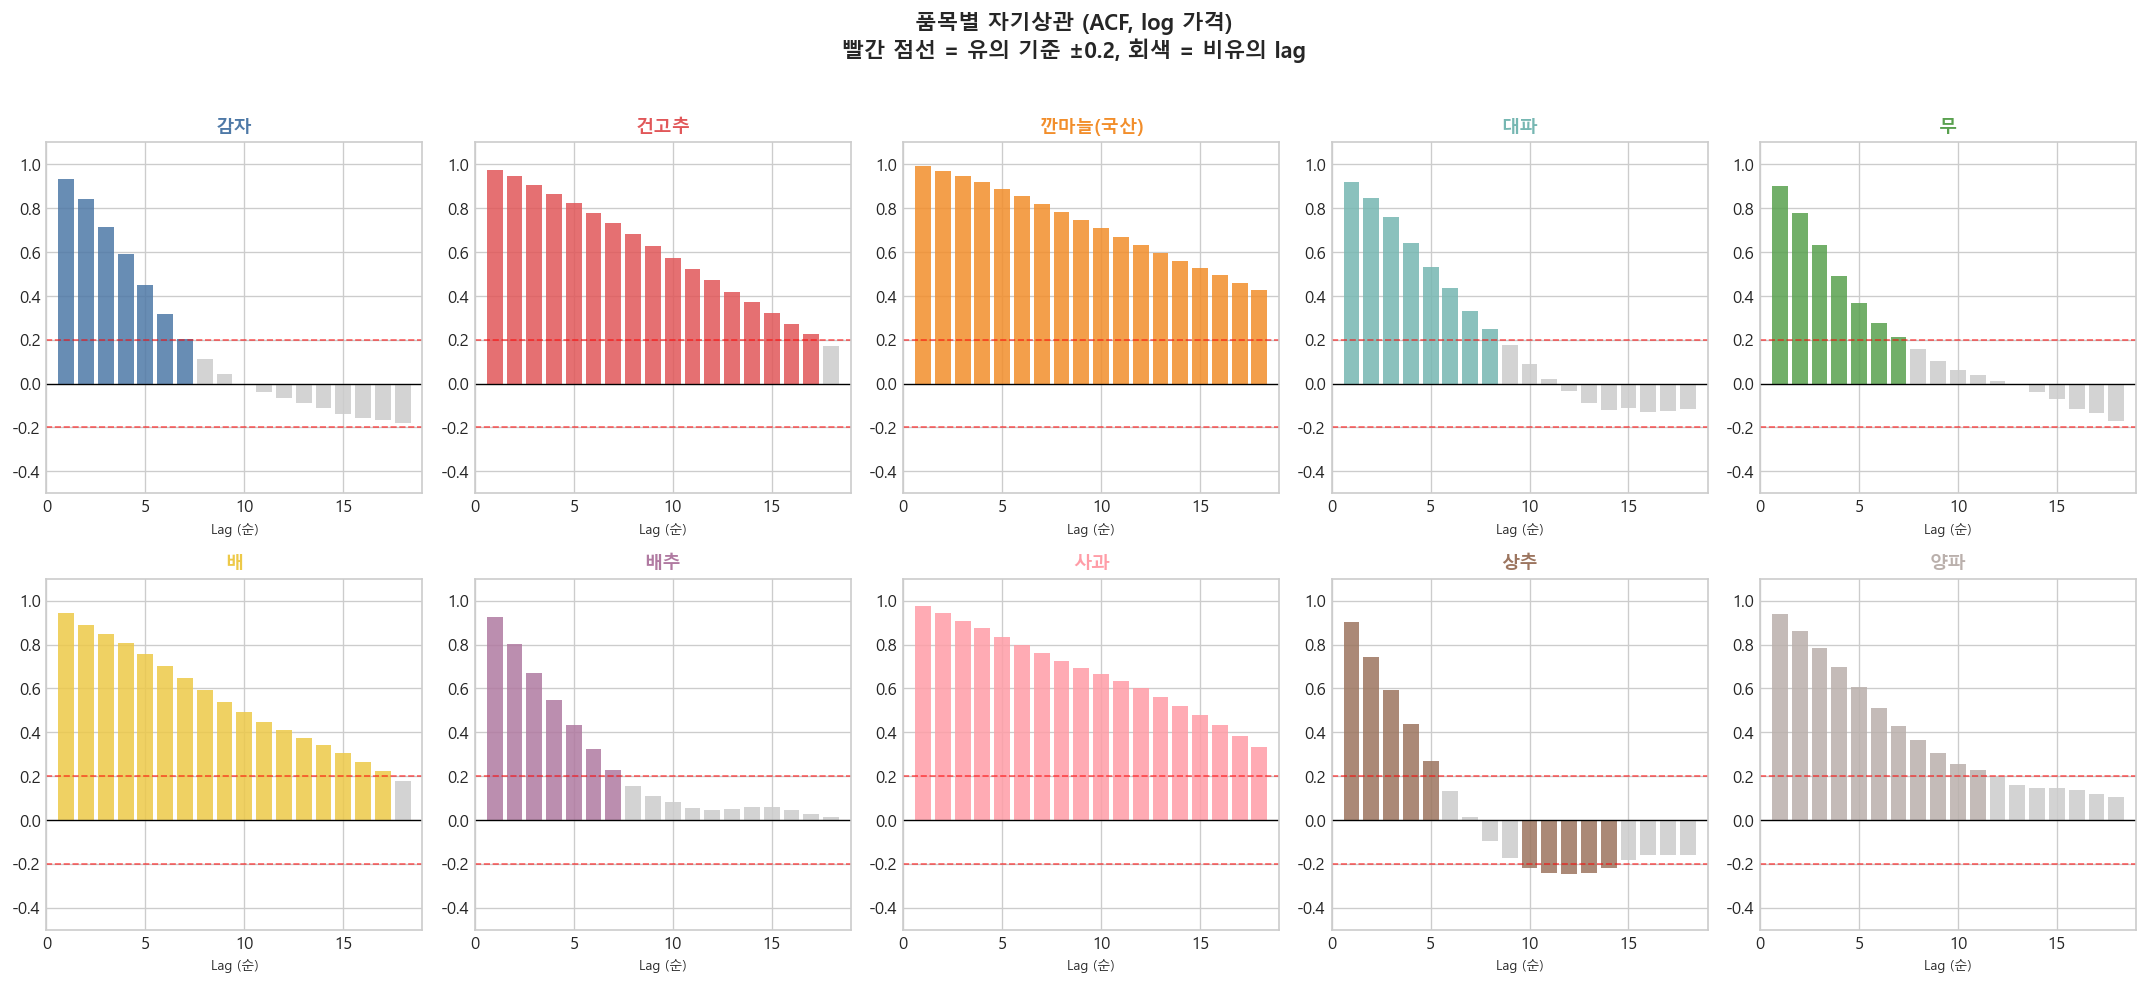


[유효 lag 범위 요약 (|ACF| > 0.2)]
  감자             : lag [1, 2, 3, 4, 5, 6] ... → 유효 최대 lag ≈ 7
  건고추            : lag [1, 2, 3, 4, 5, 6] ... → 유효 최대 lag ≈ 17
  깐마늘(국산)        : lag [1, 2, 3, 4, 5, 6] ... → 유효 최대 lag ≈ 18
  대파             : lag [1, 2, 3, 4, 5, 6] ... → 유효 최대 lag ≈ 8
  무              : lag [1, 2, 3, 4, 5, 6] ... → 유효 최대 lag ≈ 7
  배              : lag [1, 2, 3, 4, 5, 6] ... → 유효 최대 lag ≈ 17
  배추             : lag [1, 2, 3, 4, 5, 6] ... → 유효 최대 lag ≈ 7
  사과             : lag [1, 2, 3, 4, 5, 6] ... → 유효 최대 lag ≈ 18
  상추             : lag [1, 2, 3, 4, 5, 10] ... → 유효 최대 lag ≈ 14
  양파             : lag [1, 2, 3, 4, 5, 6] ... → 유효 최대 lag ≈ 11


In [24]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

lag_summary = {}

for i, item in enumerate(TARGET_ITEMS):
    s    = get_series(item)
    vals = np.log1p(s['평균가격(원)'].values)
    clr  = ITEM_COLORS[item]
    ax   = axes[i]

    max_lag = 18
    acf_vals = [pd.Series(vals).autocorr(lag=l) for l in range(1, max_lag + 1)]
    lag_summary[item] = acf_vals

    # 유의한 lag 구분
    sig_level = 0.2
    bar_colors = [clr if abs(v) > sig_level else '#CCCCCC' for v in acf_vals]

    ax.bar(range(1, max_lag + 1), acf_vals, color=bar_colors, alpha=0.85)
    ax.axhline(0,           color='black', lw=0.8)
    ax.axhline( sig_level,  color='red',   lw=1, linestyle='--', alpha=0.6)
    ax.axhline(-sig_level,  color='red',   lw=1, linestyle='--', alpha=0.6)
    ax.set_xlim(0, max_lag + 1)
    ax.set_ylim(-0.5, 1.1)
    ax.set_xlabel('Lag (순)', fontsize=8)
    ax.set_title(item, fontsize=11, fontweight='bold', color=clr)

plt.suptitle('품목별 자기상관 (ACF, log 가격)\n빨간 점선 = 유의 기준 ±0.2, 회색 = 비유의 lag',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n[유효 lag 범위 요약 (|ACF| > 0.2)]')
for item, acf_vals in lag_summary.items():
    valid = [l+1 for l, v in enumerate(acf_vals) if abs(v) > 0.2]
    first_drop = valid[-1] if valid else 0
    print(f'  {item:15s}: lag {valid[:6]} ... → 유효 최대 lag ≈ {first_drop}')

###  인사이트
- **lag 1~3 유의**: 직전 1~3순의 가격이 현재 가격에 강한 영향 → **단기 lag 피처 필수**
- **lag 36 주변 유의**: 1년(36순) 주기 자기상관 → 전년 동기 가격 lag 피처가 연간 계절성 직접 포착
- **품목별 감쇠 속도 차이**: 깻잎 등 단기 작물은 빠른 감쇠, 사과·배 등 장기 작물은 느린 감쇠 → 품목별 최적 lag 범위 다름

### 추가 피처 후보
| 피처 | 설명 | 기존 변수와의 차이 |
|------|------|------------------|
| `lag_1`, `lag_2`, `lag_3` | 직전 1~3순 가격 | **가장 강력한 단기 피처** (기존 없음) |
| `lag_6`, `lag_12` | 2개월·4개월 전 가격 | 중기 사이클 포착 |
| `lag_36` | 전년 동기 가격 | 연간 계절성 직접 포착 |
| `lag_diff_1` | lag_1 − lag_2 (1순 차분) | 가격 변화 방향성 및 속도 피처 |

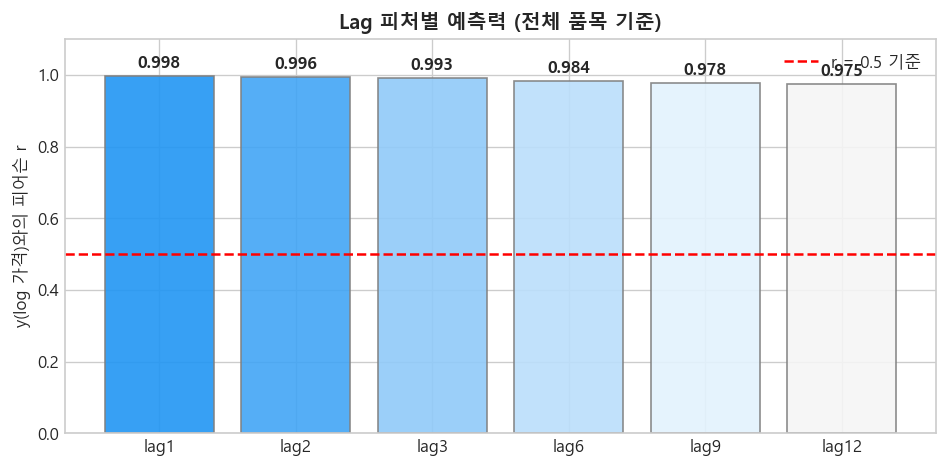


[결론] lag1~3이 핵심, lag6 이후는 보조적


In [25]:
# Lag 피처 vs 타겟 상관계수 (실질적 피처 중요도 참고)
GROUP_COLS = ['품목명','품종명','거래단위','등급']
df_s = df.sort_values(GROUP_COLS + ['time_idx']).copy()
df_s['y'] = np.log1p(df_s['평균가격(원)'])
for lag in [1,2,3,6,9,12]:
    df_s[f'lag{lag}'] = df_s.groupby(GROUP_COLS)['y'].shift(lag)

lag_cols = [f'lag{l}' for l in [1,2,3,6,9,12]]
corr_y = df_s[lag_cols + ['y']].dropna().corr()['y'].drop('y')

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(lag_cols, corr_y.values,
              color=['#2196F3','#42A5F5','#90CAF9','#BBDEFB','#E3F2FD','#F5F5F5'],
              edgecolor='gray', alpha=0.9)
ax.axhline(0.5, color='red', linestyle='--', lw=1.5, label='r = 0.5 기준')
for bar, val in zip(bars, corr_y.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('y(log 가격)와의 피어슨 r', fontsize=10)
ax.set_title('Lag 피처별 예측력 (전체 품목 기준)', fontsize=12, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

print('\n[결론] lag1~3이 핵심, lag6 이후는 보조적')

### 인사이트
- **비선형 lag 관계**: 일부 품목에서 scatter가 곡선형 → 단순 lag 값보다 **비선형 변환**(제곱, log 차이) 효과적
- **클러스터 패턴**: 가격대별 군집 존재 → 가격 레짐(저가/중가/고가) 더미 변수 유용
- **lag 상관 약한 품목**: lag 피처 단독으로 불충분 → 기상 데이터·공급량 등 **외부 정보** 더 중요할 가능성

###  추가 피처 후보
| 피처 | 설명 | 기존 변수와의 차이 |
|------|------|------------------|
| `rolling_mean_3`, `rolling_mean_6` | 3·6순 롤링 평균 | 단일 lag보다 평활화 — 노이즈 감소 |
| `rolling_std_3` | 3순 롤링 표준편차 | 국소 불안정성 — 변동성 급변 구간 포착 |
| `ewm_span6` | 지수가중이동평균(span=6) | 롤링 평균보다 최근 값에 더 높은 가중치 |
| `price_momentum` | lag_1 / lag_3 − 1 | 단기 모멘텀 방향성 피처 |

---
## 8. 핵심 인사이트 요약

EDA 결과를 바탕으로 모델링 전략 정리

C:\Users\user\AppData\Local\Temp\ipykernel_25520\3557381370.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  r_vals = df.groupby('품목명').apply(
C:\Users\user\AppData\Local\Temp\ipykernel_25520\3557381370.py:52: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


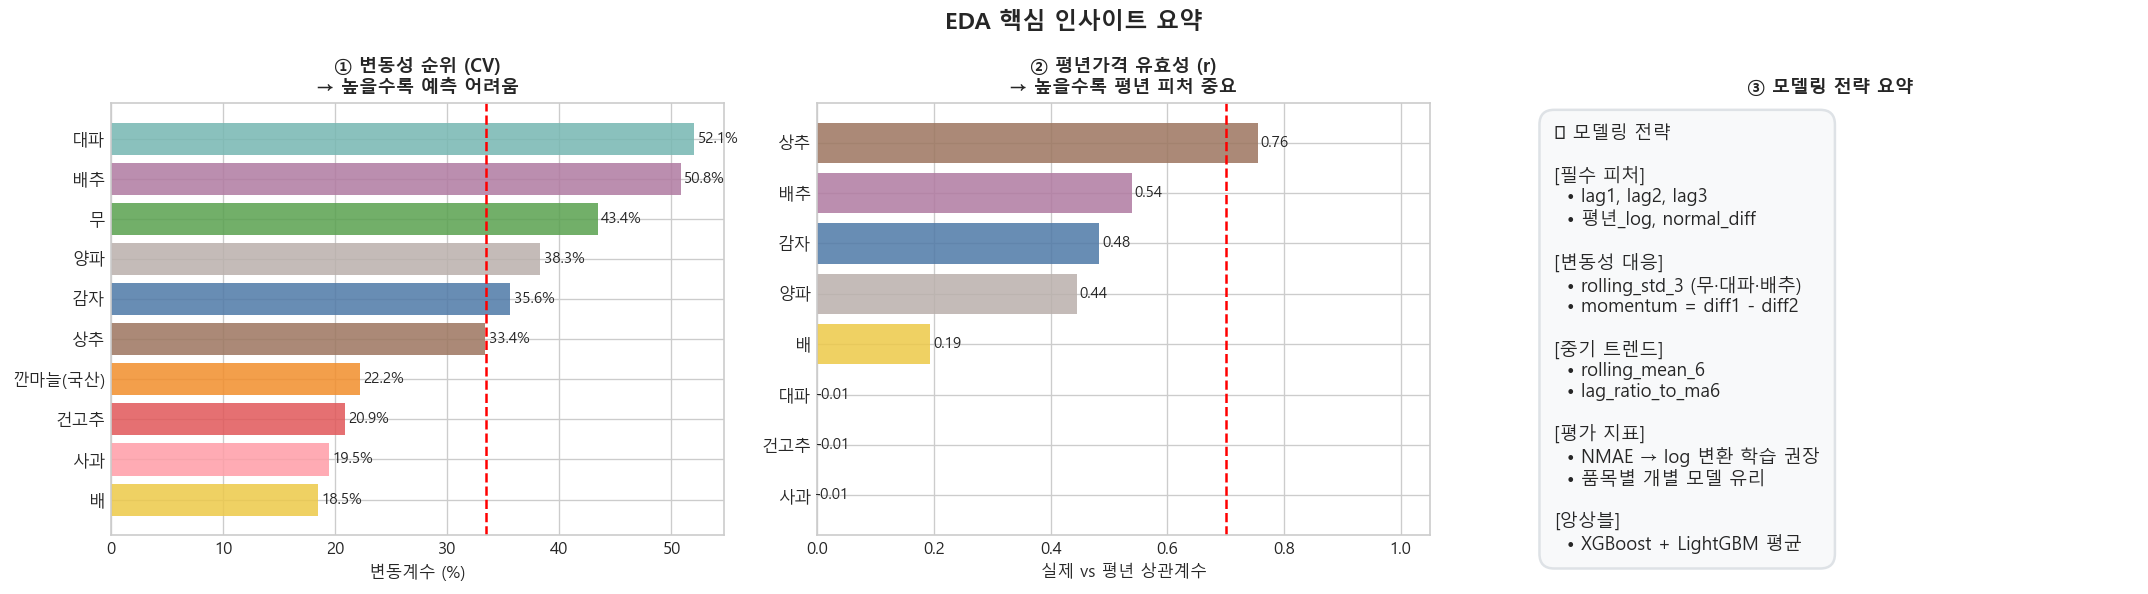

In [26]:
# 인사이트 시각화 요약 카드
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 카드1: 변동성 순위 ──
cv = df.groupby('품목명')['평균가격(원)'].agg(lambda x: x.std()/x.mean()*100).reindex(TARGET_ITEMS).sort_values(ascending=True)
colors_cv = [ITEM_COLORS[i] for i in cv.index]
axes[0].barh(cv.index, cv.values, color=colors_cv, alpha=0.85)
axes[0].axvline(cv.mean(), color='red', linestyle='--', lw=1.5)
for j, (item, val) in enumerate(zip(cv.index, cv.values)):
    axes[0].text(val + 0.3, j, f'{val:.1f}%', va='center', fontsize=9)
axes[0].set_title('① 변동성 순위 (CV)\n→ 높을수록 예측 어려움', fontsize=11, fontweight='bold')
axes[0].set_xlabel('변동계수 (%)')

# ── 카드2: 평년가격 상관 ──
r_vals = df.groupby('품목명').apply(
    lambda x: x[['평균가격(원)','평년 평균가격(원)']].corr().iloc[0,1]
).reindex(TARGET_ITEMS).sort_values(ascending=True)
colors_r = [ITEM_COLORS[i] for i in r_vals.index]
axes[1].barh(r_vals.index, r_vals.values, color=colors_r, alpha=0.85)
axes[1].axvline(0.7, color='red', linestyle='--', lw=1.5, label='r=0.7')
for j, (item, val) in enumerate(zip(r_vals.index, r_vals.values)):
    axes[1].text(val + 0.005, j, f'{val:.2f}', va='center', fontsize=9)
axes[1].set_title('② 평년가격 유효성 (r)\n→ 높을수록 평년 피처 중요', fontsize=11, fontweight='bold')
axes[1].set_xlabel('실제 vs 평년 상관계수')
axes[1].set_xlim(0, 1.05)

# ── 카드3: 피처 전략 텍스트 ──
axes[2].axis('off')
strategy = (
    "📌 모델링 전략\n\n"
    "[필수 피처]\n"
    "  • lag1, lag2, lag3\n"
    "  • 평년_log, normal_diff\n\n"
    "[변동성 대응]\n"
    "  • rolling_std_3 (무·대파·배추)\n"
    "  • momentum = diff1 - diff2\n\n"
    "[중기 트렌드]\n"
    "  • rolling_mean_6\n"
    "  • lag_ratio_to_ma6\n\n"
    "[평가 지표]\n"
    "  • NMAE → log 변환 학습 권장\n"
    "  • 품목별 개별 모델 유리\n\n"
    "[앙상블]\n"
    "  • XGBoost + LightGBM 평균"
)
axes[2].text(0.05, 0.95, strategy, transform=axes[2].transAxes,
             va='top', fontsize=11, fontfamily='Malgun Gothic',
             bbox=dict(boxstyle='round,pad=0.8', facecolor='#F8F9FA', edgecolor='#DEE2E6', lw=1.5))
axes[2].set_title('③ 모델링 전략 요약', fontsize=11, fontweight='bold')

plt.suptitle('EDA 핵심 인사이트 요약', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 피처 엔지니어링 최종 체크리스트

#### 시간 피처
- [ ] `month_sin`, `month_cos` — 월 순환 인코딩 (`month` 정수 대체)
- [ ] `sun_sin`, `sun_cos` — 순 순환 인코딩 (`순_num` 정수 대체)
- [ ] `year_trend` — 연도 기반 선형 트렌드
- [ ] `is_2020` — 코로나 충격 더미

#### Lag · 롤링 피처
- [ ] `lag_1`, `lag_2`, `lag_3`, `lag_6`, `lag_12`, `lag_36`
- [ ] `rolling_mean_3`, `rolling_mean_6`
- [ ] `rolling_std_3`, `rolling_std_6`
- [ ] `ewm_span6` — 지수가중이동평균
- [ ] `price_momentum` — lag_1 / lag_3 − 1

#### 평년 대비 피처
- [ ] `normal_ratio` — 이미 있음 (직접 피처로 활용)
- [ ] `normal_ratio_lag1`, `normal_ratio_rolling3`
- [ ] `is_above_normal` — 이진 방향성 더미

#### 변동성 · 분포 피처
- [ ] `price_zscore` — 품목별 표준화 가격
- [ ] `rolling_cv6` — 롤링 변동계수
- [ ] `is_outlier_iqr` — 이상값 더미
- [ ] `price_percentile` — 분위수 위치

#### 기존 변수 vs 추가 피처 비교
| 기존 변수 | 한계 | 추가/대체 피처 |
|-----------|------|---------------|
| `month` (정수) | 1월과 12월이 불연속 | `month_sin`, `month_cos` |
| `순_num` (정수 1~3) | 순환 구조 없음 | `sun_sin`, `sun_cos` |
| `평년가격` (단일 값) | 장기 평균 — 최근 추세 미반영 | `normal_price_ma3`, `normal_ratio` |
| `log_price` (스케일 변환) | 변환만 적용 | **타깃으로 사용** 권장 (잔차 정규성 개선) |
| *(없음)* | — | `lag_1~3`, `lag_36` (가장 강력한 피처) |

---
## 최종 정리

| 발견 | 내용 | 모델링 반영 |
|------|------|------------|
| 가격 스케일 극단적 차이 | 건고추 60만 vs 양파 866원 | **log 변환 필수**, 품목별 개별 모델 |
| 변동성 높은 품목 | 배추·무·대파 CV 높음 | `rolling_std_3`, `momentum` 피처 추가 |
| 계절성 존재 | 품목별 가격 정점/저점 월 뚜렷 | `month`, `순_num`, `sin/cos_month` |
| 평년가격 유효 | 대부분 r > 0.7 | `평년_log`, `normal_diff` 핵심 피처 |
| lag1~3 핵심 | r > 0.9, lag6 이후 급감 | `lag1~3` 중심, `rolling_mean_6` 보조 |
| 연도별 이상값 | 특정 연도 급등/급락 존재 | 이상치 처리 주의 |

